# Pulmonary fibrosis atlas and cell-type markers

This notebook reproduces the data-driven results in UniGeneX manuscript **Figure 3B–D**:

- **Figure 3B:** the pulmonary-fibrosis (PF) UGE atlas, PF-cell overlay, and aberrant-basaloid study-of-origin inset;
- **Figure 3C:** expression and prevalence of selected lineage marker genes;
- **Figure 3D:** epithelial cell-state proportions in control and PF samples.

Figure 3A is a conceptual workflow schematic and is not generated computationally.

## Data contract

The notebook expects a data root containing a `PF/` directory. Set the root with the `UNIGENEX_DATA_DIR` environment variable. If it is not set, the notebook looks for `./data/PF` relative to the working directory.

Required inputs:

| File | Purpose |
|---|---|
| `PF/UGE_atlas.h5ad` | UGE expression, final cell annotations, disease labels, UMAP and PCA |
| `PF/obs_concat_atlas.csv` | Sample and study metadata aligned to atlas cells |

Download and extract the modular archives from the [UniGeneX PF Zenodo record](https://doi.org/10.5281/zenodo.22489310), then set `UNIGENEX_DATA_DIR` to the extraction directory that contains `PF/`.

Generated panels and summary tables are written to `outputs/01_atlas_and_markers/` by default. Set `UNIGENEX_OUTPUT_DIR` to use another location.

In [1]:
from pathlib import Path
import os
import platform
import warnings

import anndata as ad
import matplotlib as mpl
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

RANDOM_SEED = 0
rng = np.random.default_rng(RANDOM_SEED)

DATA_ROOT = Path(
    os.environ.get("UNIGENEX_DATA_DIR", Path.cwd() / "data")
).expanduser().resolve()
PF_DATA_DIR = DATA_ROOT / "PF"

OUTPUT_DIR = Path(
    os.environ.get(
        "UNIGENEX_OUTPUT_DIR",
        Path.cwd() / "outputs" / "01_atlas_and_markers",
    )
).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ATLAS_PATH = PF_DATA_DIR / "UGE_atlas.h5ad"
METADATA_PATH = PF_DATA_DIR / "obs_concat_atlas.csv"
REQUIRED_FILES = [ATLAS_PATH, METADATA_PATH]

missing_files = [path for path in REQUIRED_FILES if not path.is_file()]
if missing_files:
    formatted = "\n".join(f"  - {path}" for path in missing_files)
    raise FileNotFoundError(
        "Missing required PF data files:\n"
        f"{formatted}\n"
        "Set UNIGENEX_DATA_DIR to the directory that contains PF/."
    )

sns.set_theme(style="white", context="paper")
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Data root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Data root: /import/home2/xwanaf/Img2Expr/data/Reproducibility_data
Output directory: /import/home/xwanaf/bio/scGPT-dev-temp/Atlas_integration/Reproducibility/PF_docs/outputs/01_atlas_and_markers


In [2]:
# Backed mode keeps the approximately 14 GB expression matrix on disk while
# loading the cell annotations and UMAP coordinates used in Figure 3B and 3D.
atlas = sc.read_h5ad(ATLAS_PATH, backed="r")

required_obs = {"ct_anno", "disease", "dataset"}
missing_obs = required_obs.difference(atlas.obs.columns)
if missing_obs:
    raise KeyError(f"Atlas is missing required obs columns: {sorted(missing_obs)}")
if "X_umap" not in atlas.obsm:
    raise KeyError("Atlas is missing obsm['X_umap'].")

cell_meta = atlas.obs[["ct_anno", "disease", "dataset"]].copy()
cell_meta.index = cell_meta.index.astype(str)
umap = np.asarray(atlas.obsm["X_umap"])

metadata_columns = pd.read_csv(METADATA_PATH, nrows=0).columns.tolist()
metadata_index_column = metadata_columns[0]
required_metadata = {"sample", "study"}
missing_metadata = required_metadata.difference(metadata_columns)
if missing_metadata:
    raise KeyError(
        f"Metadata table is missing columns: {sorted(missing_metadata)}"
    )

metadata = pd.read_csv(
    METADATA_PATH,
    usecols=[metadata_index_column, "sample", "study"],
).rename(columns={metadata_index_column: "cell_id"})
metadata["cell_id"] = metadata["cell_id"].astype(str)
metadata = metadata.set_index("cell_id")
cell_meta = cell_meta.join(metadata[["sample", "study"]], how="left")

missing_sample_fraction = cell_meta["sample"].isna().mean()
if missing_sample_fraction > 0:
    warnings.warn(
        f"Sample metadata are missing for {missing_sample_fraction:.2%} of atlas cells."
    )

print(atlas)
print(f"Cells: {atlas.n_obs:,}; UGE genes: {atlas.n_vars:,}")
print(f"Annotated cell types: {cell_meta['ct_anno'].nunique()}")

AnnData object with n_obs × n_vars = 946364 × 1741 backed at '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF/UGE_atlas.h5ad'
    obs: 'cell_type', 'cell_id', 'dataset_idx', 'dataset_cell_id', 'ann_finest_level', 'dataset', 'ann_level_1', 'disease', 'original_ann_nonharmonized', 'leiden_2p0', 'leiden_2p5', 'leiden_1p5', 'leiden_0p5', 'leiden_1p0', 'leiden_0p5_ct_v0', 'leiden_1p0_ct_v0', 'leiden_2p5_ct_v0', 'tmp', 'leiden_2p5_epi_v1', 'leiden_2p5_epi', 'leiden_2p5_epi_v2', 'leiden_2p5_epi_v3', 'leiden_2p5_epi_v7', 'leiden_2p5_epi_v4', 'leiden_1p_fibro_v1', 'ct_anno'
    uns: 'ann_finest_level_colors', 'dataset_colors', 'disease_colors', 'leiden_2p0_colors', 'leiden_2p5_colors', 'leiden_2p5_ct_v0_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
Cells: 946,364; UGE genes: 1,741
Annotated cell types: 50


## Figure 3B — PF UGE atlas

The main UMAP is colored by the final atlas cell-type annotation. The accompanying panels highlight PF cells and show the study of origin for aberrant basaloid cells. To make point layering deterministic, cells are shuffled with a fixed random seed before plotting.

In [3]:
CELL_TYPE_COLORS = {
    "AT1": "#ffff00",
    "AT2": "#1ce6ff",
    "Aberrant Basaloid": "#ff34ff",
    "Alveolar Mph CCL3+": "#ff4a46",
    "Alveolar Mph proliferating": "#008941",
    "Alveolar macrophages": "#006fa6",
    "B cells": "#a30059",
    "Basal": "#ffdbe5",
    "Basal-Prolif": "#7a4900",
    "CD4 T cells": "#0000a6",
    "CD8 T cells": "#63ffac",
    "Ciliated": "#b79762",
    "Ciliated MUC5AC+": "#004d43",
    "Ciliated SCGB3A2+": "#8fb0ff",
    "Classical monocytes": "#997d87",
    "DC1": "#5a0007",
    "DC2": "#809693",
    "EC aerocyte capillary": "#6a3a4c",
    "EC arterial": "#1b4400",
    "EC general capillary": "#4fc601",
    "EC venous systemic": "#3b5dff",
    "FB": "#4a3b53",
    "FB COL1A1+": "#ff2f80",
    "FB ECM": "#61615a",
    "FB ECM CHI3L2+": "#ba0900",
    "FB ECM COL1A1+": "#6b7900",
    "FB ECM SOX4+": "#00c2a0",
    "FB HAS1+": "#ffaa92",
    "Interstitial Mph perivascular": "#ff90c9",
    "Ionocyte": "#b903aa",
    "Lymphatic EC mature": "#d16100",
    "Mast cells": "#ddefff",
    "Mesothelial": "#000035",
    "Migratory DCs": "#7b4f4b",
    "Monocyte-derived Mph": "#a1c299",
    "NK cells": "#300018",
    "Neuroendocrine": "#0aa6d8",
    "Non-classical monocytes": "#013349",
    "Pericytes": "#00846f",
    "Plasma cells": "#372101",
    "Plasmacytoid DCs": "#ffb500",
    "SCGB1A1+/SCGB3A1+/SCGB3A2+": "#c2ffed",
    "SCGB3A1+/SCGB3A2+": "#a079bf",
    "SMCs": "#cc0744",
    "SMG duct": "#c0b9b2",
    "SMG-Serous": "#c2ff99",
    "Secretory MUC5AC+": "#001e09",
    "Secretory MUC5B+": "#00489c",
    "Smooth muscle": "#6f0062",
    "Squamous": "#0cbd66",
    "Suprabasal": "#eec3ff",
    "Suprabasal SCGB1A1+": "#456d75",
    "myo-FB": "#b77b68",
}

cell_types = cell_meta["ct_anno"].astype(str).to_numpy()
present_cell_types = list(pd.unique(cell_types))
missing_palette_entries = sorted(set(present_cell_types).difference(CELL_TYPE_COLORS))
if missing_palette_entries:
    fallback = sns.color_palette("husl", len(missing_palette_entries)).as_hex()
    CELL_TYPE_COLORS.update(dict(zip(missing_palette_entries, fallback)))
    warnings.warn(
        f"Generated fallback colors for: {missing_palette_entries}"
    )

plot_order = rng.permutation(atlas.n_obs)
point_colors = np.asarray([CELL_TYPE_COLORS[value] for value in cell_types])

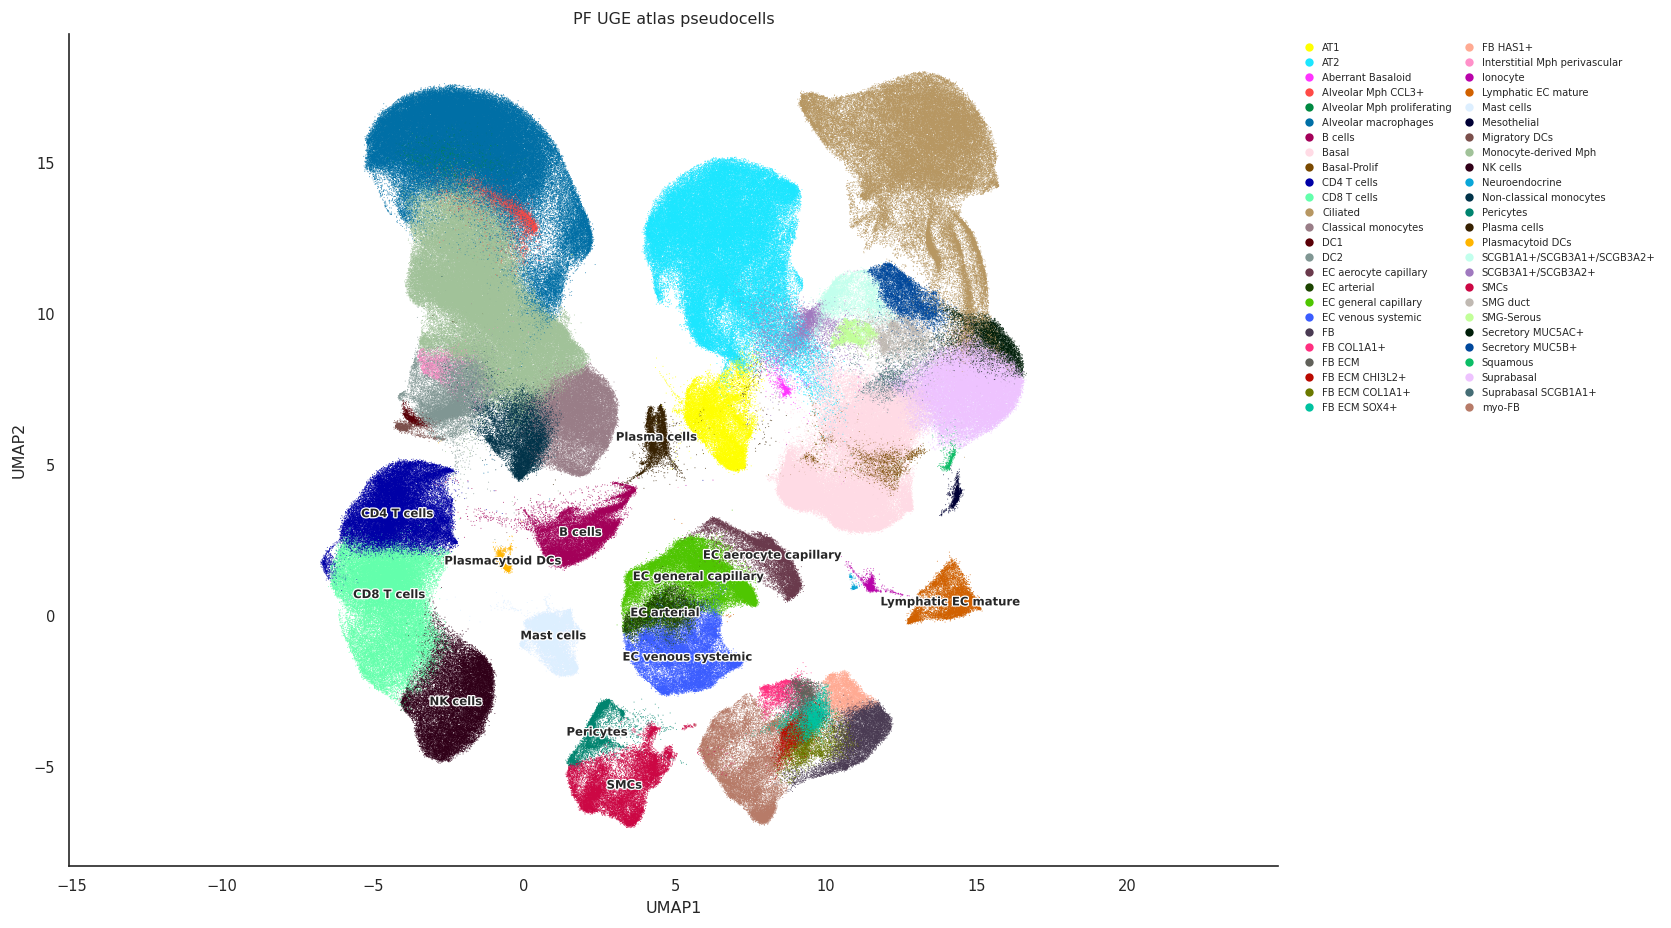

In [4]:
fig, ax = plt.subplots(figsize=(13, 9))
ax.scatter(
    umap[plot_order, 0],
    umap[plot_order, 1],
    c=point_colors[plot_order],
    s=0.35,
    linewidths=0,
    alpha=0.8,
    rasterized=True,
)

label_cell_types = [
    "NK cells", "CD4 T cells", "CD8 T cells", "Mast cells",
    "B cells", "Plasma cells", "Plasmacytoid DCs",
    "Lymphatic EC mature", "EC arterial", "EC venous systemic",
    "EC aerocyte capillary", "EC general capillary", "Pericytes",
    "SMCs",
]
for cell_type in label_cell_types:
    mask = cell_types == cell_type
    if mask.any():
        center = np.median(umap[mask], axis=0)
        ax.text(
            center[0], center[1], cell_type,
            fontsize=7, fontweight="bold", ha="center", va="center",
            path_effects=[path_effects.withStroke(linewidth=1.5, foreground="white")],
        )

legend_order = [name for name in CELL_TYPE_COLORS if name in present_cell_types]
legend_handles = [
    Line2D(
        [0], [0], marker="o", linestyle="", label=name,
        markerfacecolor=CELL_TYPE_COLORS[name], markeredgewidth=0, markersize=5,
    )
    for name in legend_order
]
ax.legend(
    handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left",
    frameon=False, ncol=2, fontsize=6, handletextpad=0.3, columnspacing=0.7,
)
ax.set(title="PF UGE atlas pseudocells", xlabel="UMAP1", ylabel="UMAP2")
ax.set_aspect("equal", adjustable="datalim")
fig.savefig(OUTPUT_DIR / "Figure3B_atlas_celltypes.png", bbox_inches="tight")
plt.show()
plt.close(fig)

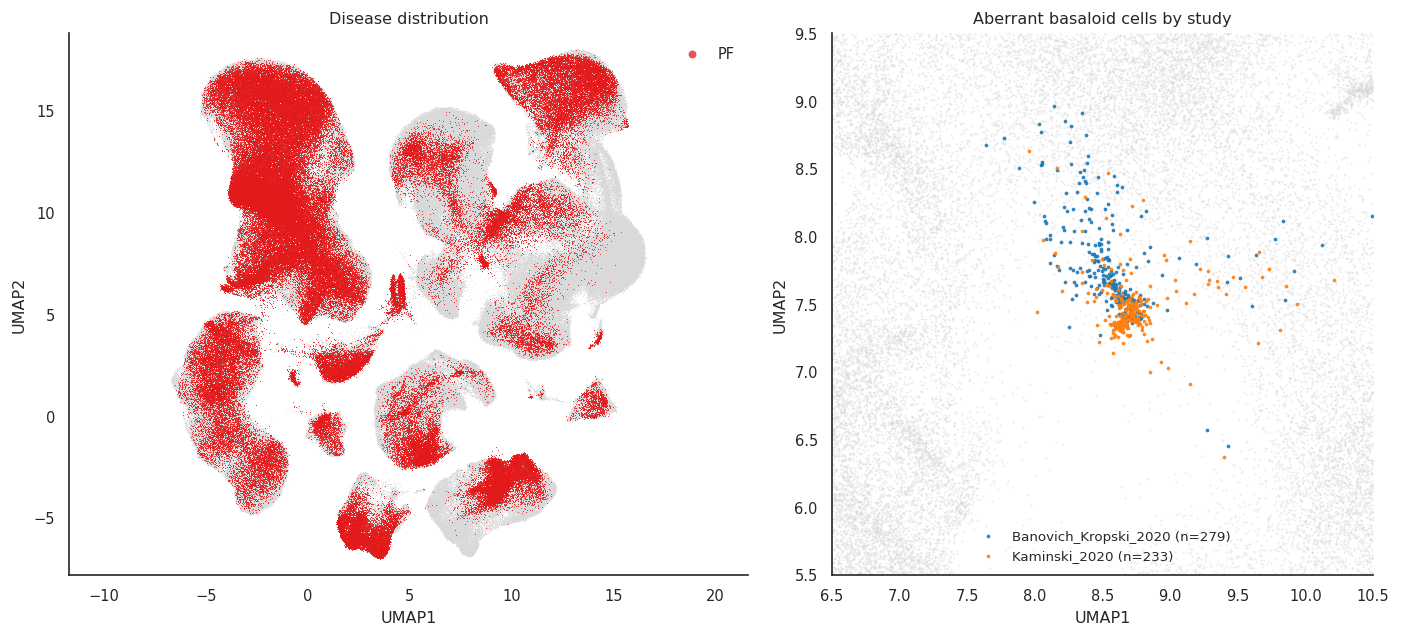

In [5]:
disease_values = cell_meta["disease"].astype(str).to_numpy()
pf_mask = disease_values == "pulmonary fibrosis"

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), constrained_layout=True)

axes[0].scatter(
    umap[:, 0], umap[:, 1], s=0.25, c="#d9d9d9",
    linewidths=0, alpha=0.55, rasterized=True,
)
axes[0].scatter(
    umap[pf_mask, 0], umap[pf_mask, 1], s=0.35, c="#e41a1c",
    linewidths=0, alpha=0.75, rasterized=True, label="PF",
)
axes[0].legend(frameon=False, markerscale=8)
axes[0].set(title="Disease distribution", xlabel="UMAP1", ylabel="UMAP2")
axes[0].set_aspect("equal", adjustable="datalim")

ab_mask = cell_types == "Aberrant Basaloid"
study_counts = cell_meta.loc[ab_mask, "study"].value_counts()
source_studies = study_counts[study_counts > 50].index.tolist()
study_palette = dict(
    zip(source_studies, sns.color_palette("tab10", len(source_studies)).as_hex())
)

x_bounds = (6.5, 10.5)
y_bounds = (5.5, 9.5)
crop_mask = (
    (umap[:, 0] >= x_bounds[0]) & (umap[:, 0] < x_bounds[1])
    & (umap[:, 1] >= y_bounds[0]) & (umap[:, 1] < y_bounds[1])
)
axes[1].scatter(
    umap[crop_mask, 0], umap[crop_mask, 1], s=1.5, c="#d9d9d9",
    linewidths=0, alpha=0.5, rasterized=True,
)
study_values = cell_meta["study"].astype(str).to_numpy()
for study in source_studies:
    mask = crop_mask & ab_mask & (study_values == str(study))
    axes[1].scatter(
        umap[mask, 0], umap[mask, 1], s=5,
        c=study_palette[study], linewidths=0, alpha=0.9,
        rasterized=True, label=f"{study} (n={mask.sum():,})",
    )
axes[1].set(
    title="Aberrant basaloid cells by study",
    xlabel="UMAP1", ylabel="UMAP2",
    xlim=x_bounds, ylim=y_bounds,
)
axes[1].legend(frameon=False, fontsize=8)
axes[1].set_aspect("equal", adjustable="box")

fig.savefig(OUTPUT_DIR / "Figure3B_disease_and_ab_sources.png", bbox_inches="tight")
plt.show()
plt.close(fig)

## Figure 3C — Cell-type marker dot plot

Only the 19 manuscript marker genes are materialized from the backed atlas. The selected matrix is then standardized gene-wise, matching the original plotting workflow while avoiding an in-memory copy of the full UGE matrix. Dot size represents the fraction of cells with a positive standardized value, and color represents mean standardized expression.

In [6]:
MARKER_GENES = [
    "PECAM1", "EPCAM", "AGER", "SFTPC", "FOXJ1", "SCGB3A2",
    "TP63", "KRT5", "KRT17", "PTPRC", "MS4A1", "CD3E",
    "JCHAIN", "CPA3", "HLA-DQB1", "CD68", "CD14", "S100A8",
    "COL1A1",
]

CELL_TYPE_ORDER = [
    "Lymphatic EC mature", "EC arterial", "EC venous systemic",
    "EC aerocyte capillary", "EC general capillary",
    "AT1", "AT2", "Ciliated", "SCGB3A1+/SCGB3A2+",
    "SCGB1A1+/SCGB3A1+/SCGB3A2+", "SMG duct", "Basal",
    "Aberrant Basaloid", "B cells", "NK cells", "CD4 T cells",
    "CD8 T cells", "Plasma cells", "Plasmacytoid DCs", "Mast cells",
    "DC1", "DC2", "Alveolar Mph CCL3+", "Alveolar macrophages",
    "Interstitial Mph perivascular", "Monocyte-derived Mph",
    "Non-classical monocytes", "Classical monocytes", "myo-FB",
    "FB COL1A1+", "FB ECM", "FB ECM CHI3L2+", "FB ECM COL1A1+",
    "FB ECM SOX4+", "FB", "FB HAS1+", "Pericytes", "SMCs",
]

available_markers = [gene for gene in MARKER_GENES if gene in atlas.var_names]
missing_markers = sorted(set(MARKER_GENES).difference(available_markers))
if missing_markers:
    warnings.warn(f"Marker genes absent from the atlas: {missing_markers}")

available_cell_types = [
    cell_type for cell_type in CELL_TYPE_ORDER if cell_type in set(present_cell_types)
]
marker_cell_mask = np.isin(cell_types, available_cell_types)
marker_adata = atlas[marker_cell_mask, available_markers].to_memory()
marker_adata.obs["ct_anno"] = pd.Categorical(
    marker_adata.obs["ct_anno"],
    categories=available_cell_types,
    ordered=True,
)

# Match the original Figure 3C workflow, but scale only the selected genes.
sc.pp.scale(marker_adata)
print(marker_adata)

AnnData object with n_obs × n_vars = 879710 × 19
    obs: 'cell_type', 'cell_id', 'dataset_idx', 'dataset_cell_id', 'ann_finest_level', 'dataset', 'ann_level_1', 'disease', 'original_ann_nonharmonized', 'leiden_2p0', 'leiden_2p5', 'leiden_1p5', 'leiden_0p5', 'leiden_1p0', 'leiden_0p5_ct_v0', 'leiden_1p0_ct_v0', 'leiden_2p5_ct_v0', 'tmp', 'leiden_2p5_epi_v1', 'leiden_2p5_epi', 'leiden_2p5_epi_v2', 'leiden_2p5_epi_v3', 'leiden_2p5_epi_v7', 'leiden_2p5_epi_v4', 'leiden_1p_fibro_v1', 'ct_anno'
    var: 'mean', 'std'
    uns: 'ann_finest_level_colors', 'dataset_colors', 'disease_colors', 'leiden_2p0_colors', 'leiden_2p5_colors', 'leiden_2p5_ct_v0_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


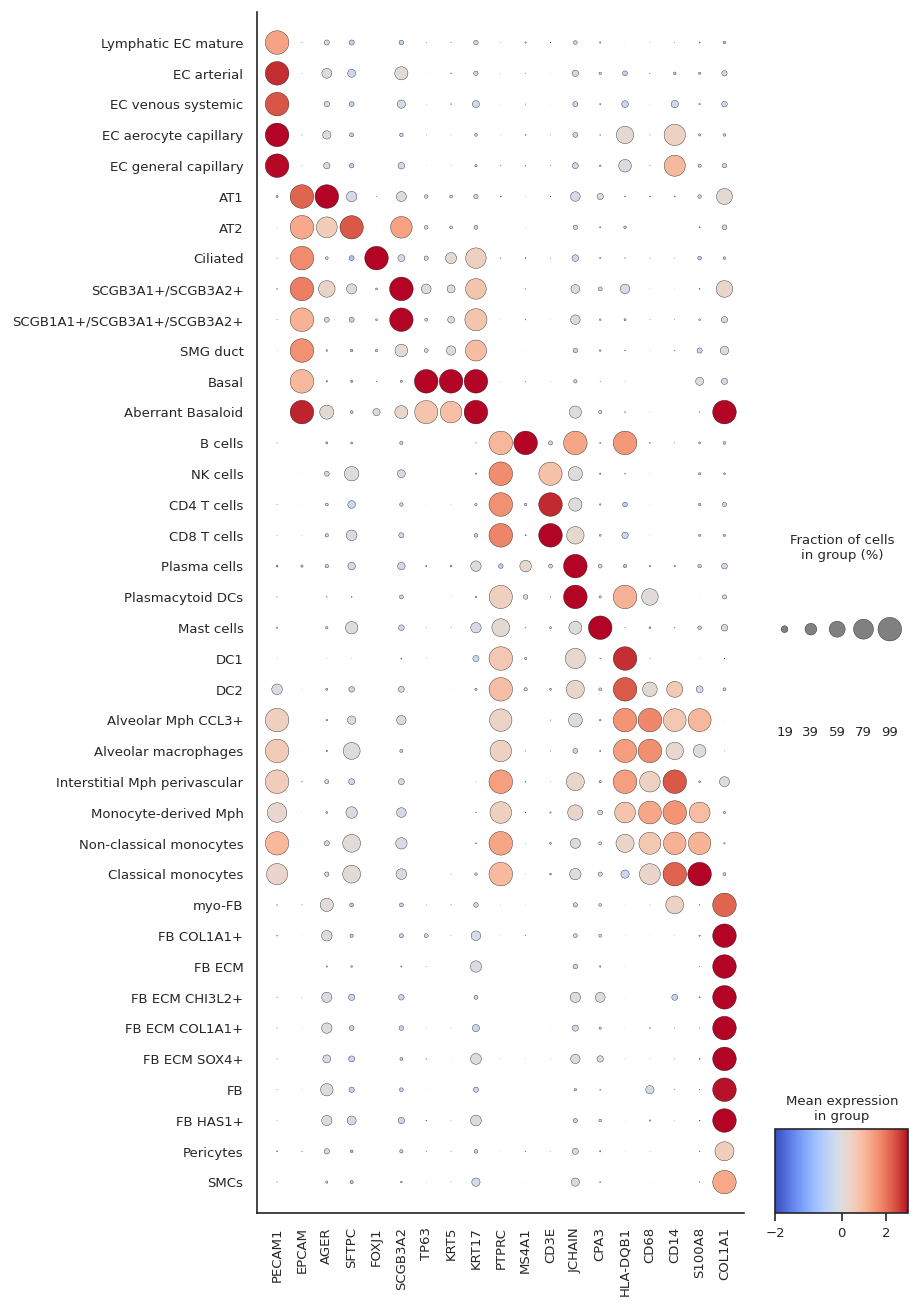

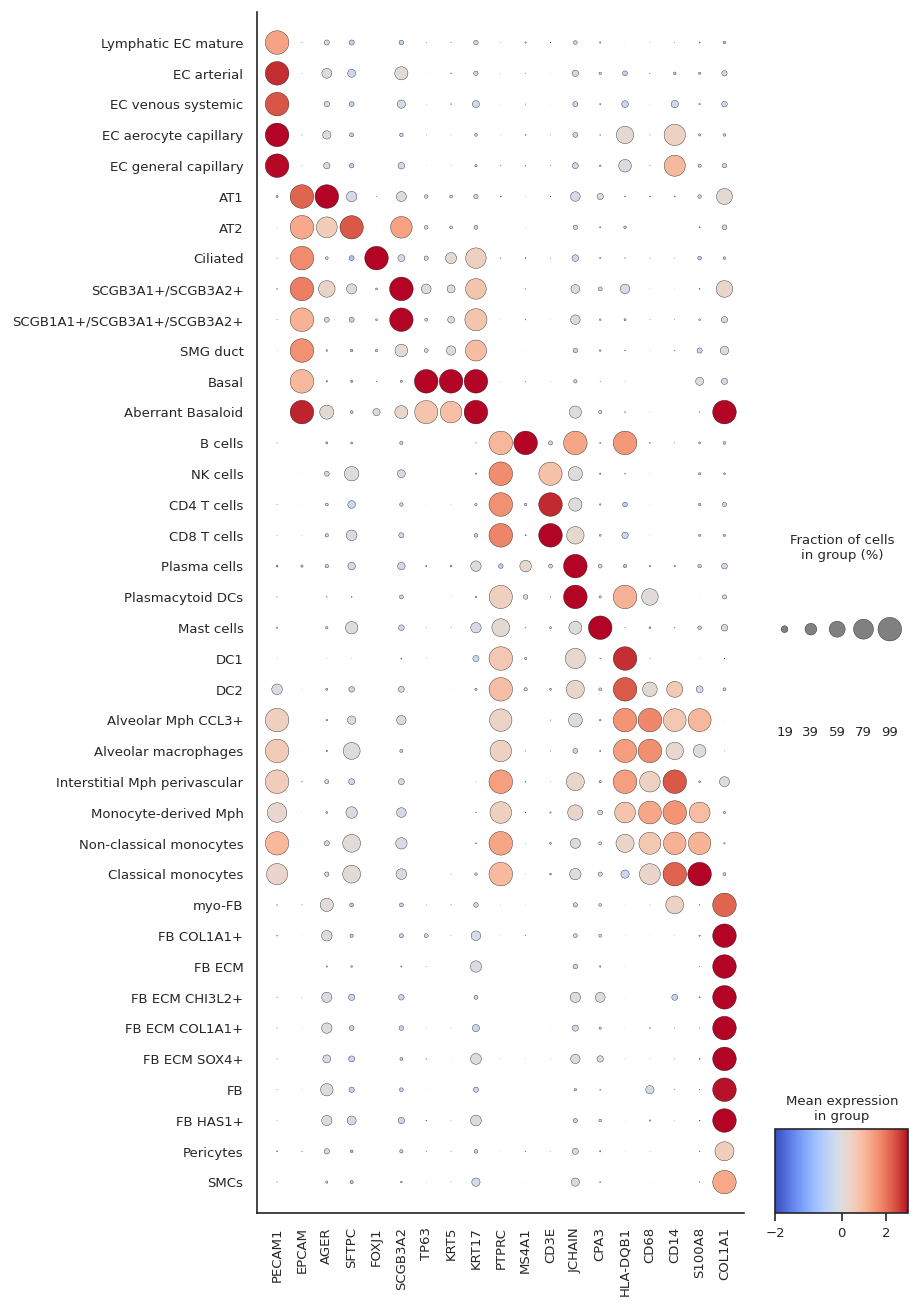

In [7]:
dotplot = sc.pl.dotplot(
    marker_adata,
    available_markers,
    groupby="ct_anno",
    categories_order=available_cell_types,
    use_raw=False,
    dendrogram=False,
    figsize=(7, 13),
    cmap="coolwarm",
    vmin=-2,
    vcenter=0,
    vmax=3,
    dot_max=0.99,
    return_fig=True,
    show=False,
)
dotplot.savefig(OUTPUT_DIR / "Figure3C_marker_dotplot.png")
dotplot.show()

## Figure 3D — Epithelial cell-state proportions

For each sample with more than 100 epithelial atlas cells, proportions are calculated within the epithelial lineage. Bars show the mean across samples and error bars show a deterministic 95% bootstrap confidence interval. The manuscript reports 334 retained samples (282 control and 52 PF).

In [8]:
EPITHELIAL_CELL_TYPES = [
    "AT1", "AT2", "Aberrant Basaloid", "Basal", "Basal-Prolif",
    "Ciliated", "Ionocyte", "Mesothelial", "Neuroendocrine",
    "SCGB1A1+/SCGB3A1+/SCGB3A2+", "SCGB3A1+/SCGB3A2+",
    "SMG duct", "SMG-Serous", "Secretory MUC5AC+",
    "Secretory MUC5B+", "Squamous", "Suprabasal",
    "Suprabasal SCGB1A1+",
]
DISEASE_ORDER = ["normal", "pulmonary fibrosis"]
MIN_EPITHELIAL_CELLS = 100

epithelial = cell_meta.loc[
    cell_meta["ct_anno"].isin(EPITHELIAL_CELL_TYPES),
    ["sample", "disease", "ct_anno"],
].dropna(subset=["sample", "disease", "ct_anno"])

sample_sizes = epithelial.groupby("sample", observed=True).size()
eligible_samples = sample_sizes[sample_sizes > MIN_EPITHELIAL_CELLS].index
epithelial = epithelial[epithelial["sample"].isin(eligible_samples)].copy()

sample_disease = epithelial.groupby("sample", observed=True)["disease"].agg(
    lambda values: values.value_counts().index[0]
)
proportions = pd.crosstab(
    epithelial["sample"],
    epithelial["ct_anno"],
    normalize="index",
).reindex(columns=EPITHELIAL_CELL_TYPES, fill_value=0.0)
proportions["disease"] = proportions.index.map(sample_disease)

sample_counts = (
    proportions["disease"]
    .value_counts()
    .reindex(DISEASE_ORDER, fill_value=0)
)
print("Retained samples by disease status:")
display(sample_counts.rename("n_samples").to_frame())

expected_counts = pd.Series(
    {"normal": 282, "pulmonary fibrosis": 52},
    name="expected_n_samples",
)
if sample_counts.to_dict() != expected_counts.to_dict():
    warnings.warn(
        "Retained sample counts differ from the manuscript expectation. "
        f"Observed={sample_counts.to_dict()}, expected={expected_counts.to_dict()}."
    )

Retained samples by disease status:


,n_samples
disease,
normal,282
pulmonary fibrosis,52


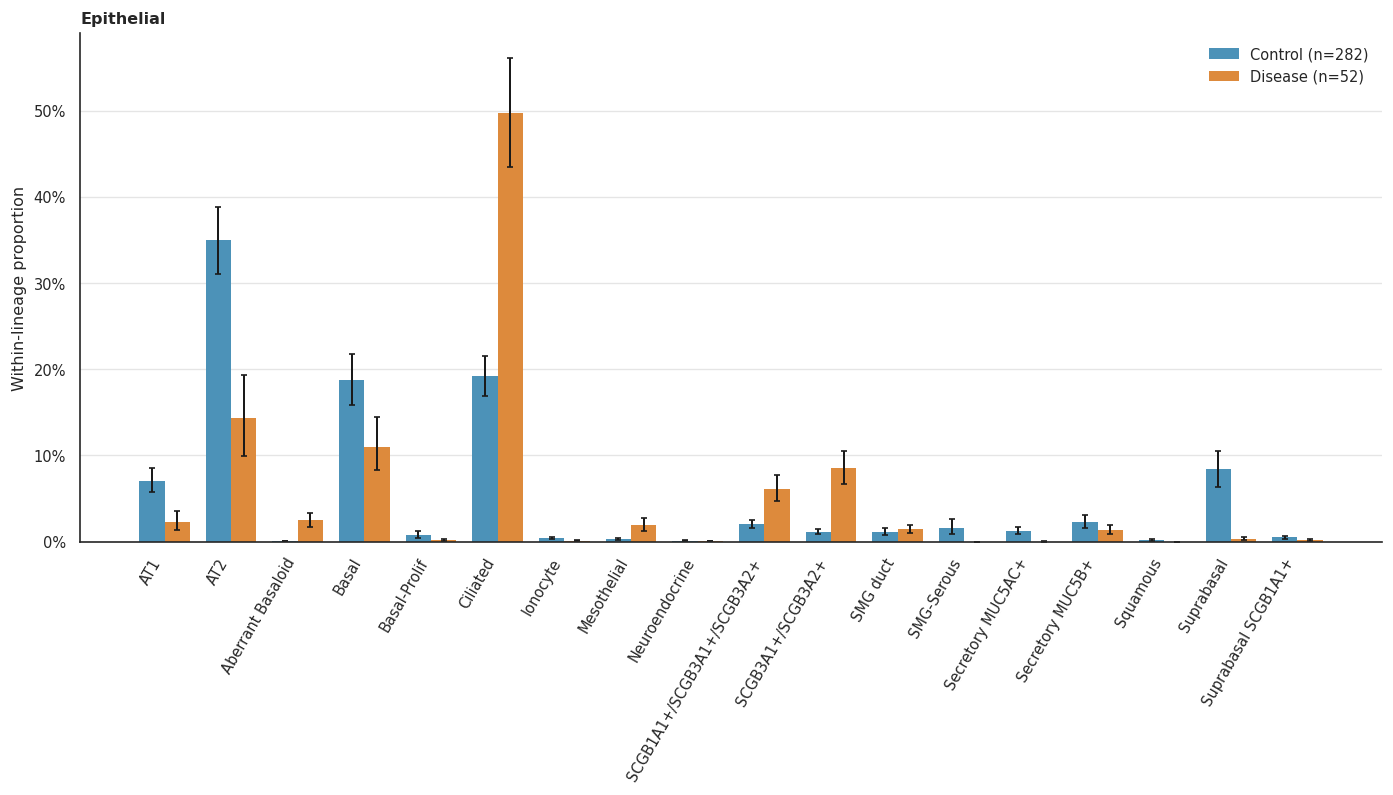

,ct_anno,disease,n_samples,mean_proportion,ci95_low,ci95_high
0,AT1,normal,282,0.070490,0.057292,0.084934
1,AT1,pulmonary fibrosis,52,0.023096,0.013518,0.035937
2,AT2,normal,282,0.349718,0.310625,0.388418
3,AT2,pulmonary fibrosis,52,0.143393,0.098889,0.193273
4,Aberrant Basaloid,normal,282,0.000526,0.000320,0.000754


In [9]:
def bootstrap_mean_ci(values, rng, n_boot=2000, confidence=0.95):
    """Return the mean and percentile bootstrap confidence interval."""
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan, np.nan, np.nan
    bootstrap_indices = rng.integers(0, values.size, size=(n_boot, values.size))
    bootstrap_means = values[bootstrap_indices].mean(axis=1)
    alpha = (1 - confidence) / 2
    lower, upper = np.quantile(bootstrap_means, [alpha, 1 - alpha])
    return values.mean(), lower, upper

bootstrap_rng = np.random.default_rng(RANDOM_SEED)
summary_rows = []
for cell_type in EPITHELIAL_CELL_TYPES:
    for disease in DISEASE_ORDER:
        values = proportions.loc[
            proportions["disease"] == disease, cell_type
        ].to_numpy()
        mean, ci_low, ci_high = bootstrap_mean_ci(values, bootstrap_rng)
        summary_rows.append({
            "ct_anno": cell_type,
            "disease": disease,
            "n_samples": values.size,
            "mean_proportion": mean,
            "ci95_low": ci_low,
            "ci95_high": ci_high,
        })

proportion_summary = pd.DataFrame(summary_rows)
proportion_summary.to_csv(
    OUTPUT_DIR / "Figure3D_epithelial_proportions_summary.csv", index=False
)

x = np.arange(len(EPITHELIAL_CELL_TYPES))
width = 0.38
plot_colors = {"normal": "#4C92B8", "pulmonary fibrosis": "#DD8A3C"}
plot_labels = {"normal": "Control", "pulmonary fibrosis": "Disease"}

fig, ax = plt.subplots(figsize=(14, 5.5))
for disease_index, disease in enumerate(DISEASE_ORDER):
    disease_summary = (
        proportion_summary[proportion_summary["disease"] == disease]
        .set_index("ct_anno")
        .reindex(EPITHELIAL_CELL_TYPES)
    )
    means = disease_summary["mean_proportion"].to_numpy()
    lower = disease_summary["ci95_low"].to_numpy()
    upper = disease_summary["ci95_high"].to_numpy()
    yerr = np.vstack([
        np.maximum(0, means - lower),
        np.maximum(0, upper - means),
    ])
    positions = x + (disease_index - 0.5) * width
    ax.bar(
        positions, means, width=width, yerr=yerr, capsize=2,
        color=plot_colors[disease], edgecolor="none",
        label=f"{plot_labels[disease]} (n={int(sample_counts[disease])})",
    )

ax.set_xticks(x)
ax.set_xticklabels(EPITHELIAL_CELL_TYPES, rotation=60, ha="right")
ax.set_ylabel("Within-lineage proportion")
ax.set_title("Epithelial", loc="left", fontweight="bold")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper right")
fig.savefig(OUTPUT_DIR / "Figure3D_epithelial_proportions.png", bbox_inches="tight")
plt.show()
plt.close(fig)

display(proportion_summary.head())

## Interpretation and limitations

The atlas visualization summarizes cell-state structure in UGE space. The proportion analysis treats samples, rather than cells, as independent observational units and presents descriptive bootstrap confidence intervals. Differences between PF and control groups should not be interpreted as causal effects; cohort composition and sampling depth may also contribute.

In [10]:
# Release the backed HDF5 handle after the selected marker matrix is in memory.
atlas.file.close()

print(f"Python: {platform.python_version()}")
print(f"anndata: {ad.__version__}")
print(f"scanpy: {sc.__version__}")
print(f"pandas: {pd.__version__}")
print(f"seaborn: {sns.__version__}")
print(f"matplotlib: {mpl.__version__}")
print(f"Completed outputs: {OUTPUT_DIR}")

Python: 3.9.19
anndata: 0.10.8
scanpy: 1.10.2
pandas: 2.2.2
seaborn: 0.13.2
matplotlib: 3.9.2
Completed outputs: /import/home/xwanaf/bio/scGPT-dev-temp/Atlas_integration/Reproducibility/PF_docs/outputs/01_atlas_and_markers
